# Could a mixed build ever beat committing to one technology?

**The question.** The companion notebook (`mc_cost_trajectories.ipynb`) assumes *winner-take-all*:
in every simulated future, the entire US nuclear build program goes to whichever technology —
traditional large reactors or small modular reactors (SMRs) — is cheaper in that future. Its
fragmentation figure shows that *splitting the program 50/50* is always more expensive. But that
result was obtained under two assumptions that stack the deck against mixing:

1. **Zero cross-technology spillover** — building large reactors taught SMR vendors nothing, and
   vice versa. If experience *did* transfer between the two technologies, an intriguing strategy
   opens up: build some of the initially-cheaper technology first, let that experience spill over,
   and switch once the other technology has been pulled down its cost curve.
2. **Perfectly linked starting costs** — the two technologies' 2030 cost estimates were drawn
   at the *same percentile* of their published ranges, so an SMR was never cheaper than a large
   reactor at the starting line. Real relative costs are far more uncertain than that.

**This notebook relaxes both assumptions and then actively searches for a winning mixed strategy.**
For every simulated future we hand an optimizer a 20-element dial — the SMR share of each year's
construction, 2031–2050 — and ask it to minimize the total (discounted, financing-inclusive) cost
of hitting that future's deployment schedule. If even a motivated optimizer, granted up to 30%
cross-technology spillover in each direction and genuinely noisy relative starting costs, cannot
beat the better of the two pure strategies, then winner-take-all is validated under much weaker
assumptions than before. If mixing *does* win somewhere, we learn exactly where and by how much.

**Discipline reminder** (same as the companion notebook): every cost trajectory here is
**conditional on an imposed deployment schedule** — these are *"what would it cost if we built
this much"* curves, never predictions of what will be built.

In [1]:
import json
import os
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports" / "mixed_build"   # this notebook's analysis exports
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))

# --- Reproducibility: one master seed, independent named streams (same policy as the
# companion notebook; every stream name here is prefixed "mixopt/" so no stream can
# collide with the companion notebook's draws) ---
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches ---
# Rank correlation between the two technologies' 2030 anchor-cost draws. 1.0 reproduces the
# companion notebook's perfectly-linked ("comonotone") draw; lower values let the relative
# starting cost vary — including futures where SMRs start cheaper than large reactors.
RHO_BOAK = 0.5
RHO_BOAK_SWEEP = [0.0, 0.5, 0.9, 1.0]          # sensitivity sweep (S8)

# Cross-technology spillover: each simulated future draws two fractions uniformly on
# [0, X_SPILL_MAX] — how much of one technology's US build experience also teaches the
# other technology's vendors (large->SMR and SMR->large are drawn independently).
X_SPILL_MAX = 0.30

# The US historical large-reactor fleet does NOT flow to SMRs through the drawn spillover:
# the empirical SMR learning-rate range already embeds any benefit from those prior builds
# (the companion notebook's D8' convention). Only post-2030 program builds spill over.
HIST_CROSS_TECH = False

COPULA_SET = "moderate"                        # lr <-> boak correlation set (as companion)

# Optimizer-funnel controls (S6): a draw goes to the expensive free optimizer if any mixed
# candidate in the cheap vectorized screen comes within EPS_FLAG of the best pure corner;
# AUDIT_FRAC of draws are polished regardless, to verify the screen misses nothing.
EPS_FLAG = 0.005
AUDIT_FRAC = 0.03
TOL_WIN = 0.001          # a mixed strategy "wins" if it beats the best corner by > 0.1%

# Draw counts (environment overrides let test runs stay cheap without editing the notebook)
N_DRAWS_OPT = int(os.environ.get("MIXOPT_DRAWS", 2000))         # per schedule, main analysis
N_SWEEP = int(os.environ.get("MIXOPT_SWEEP_DRAWS", 1000))       # per rho_boak sweep point (S8)
SWEEP_SCHED = "McKinsey GEP 2025"              # representative schedule for the S8 sweep

# --- Model frame (identical to the companion notebook) ---
YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-2.0, -1.0, 0.0, 1.0])
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

# The optimizer's decision variable: SMR share of each build year 2031-2050
BUILD_YEARS = np.arange(2031, 2051)
N_P = len(BUILD_YEARS)                          # 20
BUILD_SLICE = slice(yi(2031), yi(2050) + 1)

print(f"notebook dir : {NB_DIR}")
print(f"switches     : rho_boak={RHO_BOAK}, x_spill_max={X_SPILL_MAX}, copula={COPULA_SET}, "
      f"draws/schedule={N_DRAWS_OPT}, sweep draws={N_SWEEP}")
print(f"funnel       : eps_flag={EPS_FLAG:.1%}, audit={AUDIT_FRAC:.0%}, win tolerance={TOL_WIN:.1%}")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
switches     : rho_boak=0.5, x_spill_max=0.3, copula=moderate, draws/schedule=2000, sweep draws=1000
funnel       : eps_flag=0.5%, audit=3%, win tolerance=0.1%


## What is different from the companion notebook — and how to turn each change off

| Change | What it does | Why | "Off" setting |
|---|---|---|---|
| **Split anchor-cost draw** | Each technology's 2030 cost is drawn on its own latent, linked by rank correlation `RHO_BOAK`. Published ranges are unchanged. | Real relative costs are uncertain; the linked draw never let SMRs start cheaper. | `RHO_BOAK = 1.0` reproduces the companion draw exactly |
| **Cross-technology spillover** | Two drawn fractions `x_ls` (large→SMR) and `x_sl` (SMR→large), each U(0, 30%), feed one technology's post-2030 US builds into the other's discounted cross-firm learning channel. | The only mechanism by which "build cheap traditional first" could ever pay off. | Force both to 0 (the S8 check does this) |
| **Optimizer instead of winner-take-all** | A per-future optimizer chooses the SMR share of every build year to minimize discounted financed program cost. | Tests *all* mixed strategies, not just 50/50. | The two pure strategies are always in the candidate set |

Everything else — the six deployment schedules, the PRIS-based international stocks, the
learning-curve engine, the construction-duration model, and the ReEDS financing replication —
is **ported unchanged** from the companion notebook, and the S9 QA cells assert that at the
"off" settings this notebook reproduces the companion engine bit-for-bit.

## The six deployment schedules

Read from `inputs/nuclear_learning/US_SCHEDULES.csv` — the single source of truth exported by
the companion notebook (this notebook deliberately does *not* redefine them). Values are
capacity indices (100 = the 97 GW 2024 fleet); the working GW basis everywhere is the index
read as literal GW **minus a flat 3 GW**, exactly as in the companion notebook and the ReEDS
mandate files.

In [2]:
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")

# Display names for the machine tokens in the CSV, in fixed ascending-ambition order
TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"

US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

print("schedules loaded (2050 capacity in working GW basis):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {US_SCHEDULES[name][-1] - OFFSET_GW:5.0f} GW")

schedules loaded (2050 capacity in working GW basis):
  EIA 2026 AEO high        114 GW
  Abou-Jaoude mod          131 GW
  IAEA high                169 GW
  McKinsey GEP 2025        197 GW
  COP28 tripling pledge    297 GW
  2025 EO                  397 GW


## Historical and international experience (ported from companion S3)

The learning engine needs to know how much nuclear construction experience exists outside the
US program: the IAEA's PRIS reactor database provides every unit ever grid-connected, the
under-construction pipeline, and region-by-region growth projections. All of this is identical
to the companion notebook — see its S3 for the full plain-language walkthrough.

In [3]:
# Ported verbatim from mc_cost_trajectories.ipynb S3 (regional milestones, PRIS load,
# retirement identity, committed pipeline, historical stocks).
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2034
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

_ever = PRIS_UNITS[PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")

PRIS fleet loaded: 417 operational, 62 under construction


In [4]:
# Ported verbatim from companion S3: foreign stocks on the u grid, plus this notebook's
# per-schedule GROSS GW ADDITIONS (the quantity the optimizer splits between technologies).
def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through 2034 (real units, no double counting)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 60.0 + 20.0*u)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

REGION_STOCK = {}
for r in REGIONS:
    m = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m

# US gross GW added per year under each schedule, counted from the 2030 anchor. This is the
# pie the optimizer divides: GW_ADD[sched][t] * p(t) goes to SMRs, the rest to large reactors.
US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD = {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow

print("total post-2030 gross additions per schedule (GW):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {GW_ADD[name].sum():6.1f} GW over {int((GW_ADD[name] > 0).sum())} build years")

total post-2030 gross additions per schedule (GW):
  EIA 2026 AEO high        20.7 GW over 15 build years
  Abou-Jaoude mod          36.4 GW over 20 build years
  IAEA high                75.7 GW over 20 build years
  McKinsey GEP 2025       103.4 GW over 20 build years
  COP28 tripling pledge   203.4 GW over 20 build years
  2025 EO                 303.4 GW over 20 build years


## The learning-curve engine, extended with cross-technology spillover

The engine is the companion notebook's (S5 there, with the full D1–D12 derivation): each
technology's overnight capital cost falls as its **own-design** experience (full learning rate)
and its **cross-firm** experience (other vendors + international builds, discounted to ⅓
strength) accumulate, anchored so the 2030 cost equals the drawn estimate exactly.

**The one extension:** the cross-firm channel gains an optional cross-*technology* term. When
technology A builds `N_A(t)` units after 2030, a drawn fraction `x` of those units also counts
toward technology B's cross-firm experience:

$$A_B(t) \mathrel{+}= x \cdot N_A(t)$$

Cross-technology experience is treated exactly like other "not your own design" experience —
worth ⅓ of an own build, which is what the cross-firm channel already encodes. With `x = 0`
the extension vanishes and the engine is bit-for-bit the companion's (asserted in S9). The
historical pre-2030 US fleet is deliberately **excluded** from this channel (see the S1 switch
`HIST_CROSS_TECH`): the SMR learning-rate evidence already embeds it.

In [5]:
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock

def intl_stock(world):
    """Theta-weighted foreign post-anchor stock S_KV, shape (n_draws, T) — depends only on the
    drawn global-deployment position u, so callers that evaluate many share profiles for the
    same worlds compute it once and pass it back in (the optimizer's hot loop)."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_KV = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_KV += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    return S_KV

def experience_channels(world, tech, n_us, n_oth=None, x_in=None, S_KV=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).

    Ported from the companion notebook with two optional additions (both default off):
      n_oth: the OTHER technology's cumulative post-anchor US units, (T,) or (n_draws, T);
      x_in:  the drawn incoming cross-technology spillover fraction, scalar or (n_draws,).
    When both are given, x_in * n_oth joins the cross-firm channel — cross-technology
    experience learns at the same discounted rate as any other not-own-design experience.
    S_KV: optional precomputed intl_stock(world) (pure caching, no change in values).
    """
    n = len(world)
    if S_KV is None:
        S_KV = intl_stock(world)
    N_us = np.broadcast_to(np.asarray(n_us, float), (n, T))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    # US historical fleet counts toward LARGE only (companion D8'): crediting the ~140-unit
    # LWR stock to SMRs would double-count what the empirical SMR learning-rate range embeds.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + world["s"].values[:, None]*(conv*H_ALL_W + S_KV)
    if n_oth is not None and x_in is not None:
        N_oth = np.broadcast_to(np.asarray(n_oth, float), (n, T))
        x = np.asarray(x_in, float)
        if x.ndim == 1:
            x = x[:, None]
        oth = oth + x * N_oth                    # the cross-technology spillover term
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, n_oth=None, x_in=None, ces_rho=None, S_KV=None):
    """Production OCC engine (companion D11/D12, ported verbatim; the two cross-tech arguments
    just pass through to experience_channels). Returns $/kW (2022 USD), (n_draws, T)."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

## Construction durations and financing (ported from companion S6–S7)

Durations come from the INL series-reduction curves (each vendor's next project gets faster);
financing replicates ReEDS's own overnight-cost → financed-cost multiplier, with the
interest-during-construction part evaluated at each draw's learned duration. Both are verbatim
ports — the duration model sees only a technology's **own** builds (spillover shortens costs,
not schedules), and the QA suite re-pins the financing port to the ReEDS engine's regression value.

In [6]:
# Ported verbatim from companion S6: PRIS duration panel -> residual dispersion sig_hat.
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months, FNC -> COD) per draw-year, from the INL series curves.
    Ported verbatim; n_us is the technology's OWN cumulative post-anchor US units — the
    series-reduction clock runs on a vendor's own projects, so cross-technology spillover
    lowers costs but never shortens the other technology's schedules."""
    n = len(world)
    N_us = np.broadcast_to(np.asarray(n_us, float), (n, T))
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

print(f"duration panel: {len(DUR_UNITS)} units, residual sd = {sig_hat:.3f} log-months")

duration panel: 21 units, residual sd = 0.116 log-months


In [7]:
# Ported verbatim from companion S7: ReEDS financial inputs + the IDC (ccmult) machinery.
FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        out["sched"][tech] = frac[frac > 0]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to `n_years` bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def _ccm_table(tech):
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for nyr in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], nyr)
        exps = np.arange(nyr) + 0.5
        table[nyr] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    return table

# Precomputed once (the optimizer evaluates ccmult_grid thousands of times per draw)
CCM_TABLE = {tech: _ccm_table(tech) for tech in TECH}

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array (identical values to
    ccmult_from_duration, element by element; table precomputed above)."""
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return CCM_TABLE[tech][n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech, use_itc=False):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) — verbatim port."""
    assert not use_itc, "ITC variant deliberately not implemented"
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030

print("financing loaded; full multiplier at 2035, at each tech's default duration:")
for tech, default_mo in [("large", 72.0), ("smr", 36.0)]:
    ccm = ccmult_from_duration(default_mo, FIN["interest_base"][yi(2035)], FIN["sched"][tech])
    print(f"  {tech}: ccmult = {ccm:.4f}, fin_mult_noITC = {ccm*FIN_REST[tech][yi(2035)]:.4f}")

financing loaded; full multiplier at 2035, at each tech's default duration:
  large: ccmult = 1.2681, fin_mult_noITC = 1.5145
  smr: ccmult = 1.0898, fin_mult_noITC = 1.3015


## The parameter draw: four latent axes instead of three

The companion notebook joins three latent uncertainty axes with a Gaussian copula: learning
rate, anchor cost, and global deployment position. Here the **anchor-cost axis is split in
two** — one latent per technology — joined by the rank correlation `RHO_BOAK`:

- At `RHO_BOAK = 1.0` the two latents collapse into one and the draw is *exactly* the
  companion notebook's: both technologies always at the same percentile of their range.
- Below 1.0, the percentiles decouple. Since the SMR range ($5,500–10,000/kW) is wider than
  the large-reactor range ($5,250–7,750/kW) but starts higher, decoupling is the only way a
  future can start with SMRs *cheaper* than large reactors — the table below shows how often.

Two new columns also appear in every drawn world: the cross-technology spillover fractions
`x_ls` (large→SMR) and `x_sl` (SMR→large), each uniform on [0, 30%] and independent — a wide,
deliberately generous range, since the paper's baseline convention is zero.

In [8]:
RHO_SETS = {"zero": 0.0, "moderate": -0.3, "strong": -0.6}   # lr <-> boak correlation (companion)
LATENTS = ["lr", "boak_large", "boak_smr", "u"]

def corr_matrix4(rho_key, rho_boak):
    """4x4 latent correlation: lr couples to BOTH anchor-cost latents at the companion's
    lr<->boak value; the two anchor-cost latents couple at rho_boak; u stays independent."""
    C = np.eye(4)
    C[0, 1] = C[1, 0] = RHO_SETS[rho_key]
    C[0, 2] = C[2, 0] = RHO_SETS[rho_key]
    C[1, 2] = C[2, 1] = rho_boak
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"correlation matrix (rho_boak={rho_boak}) is not positive definite: {ev}"
    return C

def draw_world_4(n, rho_key, rho_boak, rng):
    """Draw n worlds with the split anchor-cost latent and the two cross-tech spillover columns.

    rho_boak >= 1 takes the exact comonotone path: the copula is built with the two
    anchor-cost latents independent, then the SMR latent is OVERWRITTEN with the large
    latent — this reproduces the companion draw exactly AND consumes the random stream
    identically at every rho_boak, so sweep points share common random numbers.
    """
    comonotone = rho_boak >= 1.0
    C = corr_matrix4(rho_key, 0.0 if comonotone else rho_boak)
    Z = rng.standard_normal((n, 4)) @ np.linalg.cholesky(C).T
    U = stats.norm.cdf(Z)
    if comonotone:
        U[:, 2] = U[:, 1]
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + U[:, 0]*(t["lr_hi"] - t["lr_lo"])   # comonotone (as companion)
    w["boak_large"] = TECH["large"]["boak_lo"] + U[:, 1]*(TECH["large"]["boak_hi"] - TECH["large"]["boak_lo"])
    w["boak_smr"] = TECH["smr"]["boak_lo"] + U[:, 2]*(TECH["smr"]["boak_hi"] - TECH["smr"]["boak_lo"])
    w["u"] = U[:, 3]
    w["s"] = rng.uniform(0.0, 1.0, n)
    w["n_vendors"] = rng.integers(4, 9, n)
    w["conv_full"] = rng.integers(0, 2, n)
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)
    w["dur_z"] = rng.standard_normal(n)
    w["x_ls"] = rng.uniform(0.0, X_SPILL_MAX, n)     # cross-tech spillover: large -> SMR
    w["x_sl"] = rng.uniform(0.0, X_SPILL_MAX, n)     # cross-tech spillover: SMR -> large
    return w

# How often do SMRs start cheaper than large reactors, as a function of rho_boak alone?
_probe = {rb: draw_world_4(20000, COPULA_SET, rb, rng_stream(f"mixopt/probe/{rb}"))
          for rb in RHO_BOAK_SWEEP}
smr_cheaper = pd.Series({rb: (w["boak_smr"] < w["boak_large"]).mean()
                         for rb, w in _probe.items()}, name="P(SMR starts cheaper)")
smr_cheaper.index.name = "rho_boak"
print("Fraction of futures where the SMR 2030 anchor cost is below the large-reactor one:")
print(smr_cheaper.round(3).to_string())
del _probe

Fraction of futures where the SMR 2030 anchor cost is below the large-reactor one:
rho_boak
0.0    0.222
0.5    0.142
0.9    0.023
1.0    0.000


In [9]:
# Draw the six per-schedule worlds for the main analysis, and cache their international
# stocks (S_KV depends only on the drawn u, never on the optimizer's share profile).
WORLDS, SKV = {}, {}
for sched in SCHED_ORDER:
    world = draw_world_4(N_DRAWS_OPT, COPULA_SET, RHO_BOAK,
                         rng_stream(f"mixopt/world/{SCEN_TOKEN[sched]}"))
    WORLDS[sched] = world
    SKV[sched] = intl_stock(world)
print(f"drew {N_DRAWS_OPT} worlds per schedule x {len(SCHED_ORDER)} schedules "
      f"(rho_boak={RHO_BOAK}, x in U(0, {X_SPILL_MAX}))")

drew 2000 worlds per schedule x 6 schedules (rho_boak=0.5, x in U(0, 0.3))


## The cost of a blended program

Given a share profile `p` — the SMR fraction of each build year's GW — the program's cost in a
drawn world is computed in four steps, all reusing the ported engine:

1. **Split the schedule.** Each year's GW additions divide into SMR and large-reactor builds;
   cumulative unit counts per technology follow from the unit sizes (0.3 GW / 1.0 GW).
2. **Learned costs.** Each technology's overnight cost path responds to its own builds (full
   strength), other vendors + international builds (⅓ strength), and now the *other
   technology's* builds (⅓ strength × the drawn spillover fraction).
3. **Financing.** Each technology's cost is marked up by ReEDS's financing multiplier, with
   interest-during-construction at that year's learned construction duration.
4. **Total.** Sum GW-weighted financed cost over all build years, discounted to 2030 — the
   same functional the companion notebook uses to rank technologies (its "issue 8" default).

The result: `program_cost_batch(world, sched, p)` — one number per drawn world, lower is
cheaper. The two pure strategies are just `p = 0` (all large) and `p = 1` (all SMR).

In [10]:
def embed_shares(p):
    """Lift a share profile over the 20 build years (2031-2050) onto the full YEARS grid
    (zeros before 2031, where no post-anchor builds exist). Accepts (20,) or (n_draws, 20)."""
    p = np.asarray(p, float)
    out = np.zeros(p.shape[:-1] + (T,))
    out[..., BUILD_SLICE] = p
    return out

def split_units(sched, p_full):
    """Cumulative post-anchor US units per technology implied by SMR-share profile p_full."""
    gw = GW_ADD[sched]
    n_smr = np.cumsum(gw * p_full, axis=-1) / TECH["smr"]["unit_gw"]
    n_large = np.cumsum(gw * (1.0 - p_full), axis=-1) / TECH["large"]["unit_gw"]
    return n_large, n_smr

def program_cost_batch(world, sched, p, S_KV=None, x_zero=False, undiscounted=False):
    """Discounted financed cost of the blended build program, one value per drawn world.

    p: SMR-share profile — (20,) applied to every draw, or (n_draws, 20) per-draw profiles.
    x_zero: force both cross-technology spillover fractions to zero (sensitivity/QA).
    undiscounted: report the plain (non-discounted) GW-weighted total instead.
    """
    p_full = embed_shares(p)
    n_large, n_smr = split_units(sched, p_full)
    x_ls = 0.0 if x_zero else world["x_ls"].values
    x_sl = 0.0 if x_zero else world["x_sl"].values
    fc = {}
    for tech, n_own, n_oth, x_in in (("smr", n_smr, n_large, x_ls),
                                     ("large", n_large, n_smr, x_sl)):
        occ = occ_paths_ces(world, tech, n_own, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
        dur = duration_paths(world, tech, n_own)
        fc[tech] = occ * ccmult_grid(dur, tech) * FIN_REST[tech][None, :]
    w_t = GW_ADD[sched] / (1.0 if undiscounted else DISC)
    blend = p_full * fc["smr"] + (1.0 - p_full) * fc["large"]
    return (blend * w_t).sum(axis=-1)

# --- Fast single-draw path for the optimizer's hot loop ---
class _SeriesView:
    __slots__ = ("values",)
    def __init__(self, a):
        self.values = a

class WorldRow:
    """A one-draw view of a world DataFrame with dict-speed column access. The free optimizer
    evaluates the objective thousands of times per draw; pandas row indexing would dominate
    the runtime. Duck-types the two things the engine uses: world[col].values and len(world).
    S9 asserts this path reproduces program_cost_batch on the full DataFrame exactly."""
    def __init__(self, world, i):
        self._cols = {c: _SeriesView(world[c].values[i:i+1]) for c in world.columns}
    def __getitem__(self, c):
        return self._cols[c]
    def __len__(self):
        return 1

def make_draw_objective(world, i, sched, S_KV_full, x_zero=False):
    """Objective C_d(p) for draw i as a plain function of the 20-element share profile."""
    row = WorldRow(world, i)
    skv = S_KV_full[i:i+1]
    def f(p):
        return program_cost_batch(row, sched, np.clip(p, 0.0, 1.0),
                                  S_KV=skv, x_zero=x_zero)[0]
    return f

### A worked example (one future, one strategy)

To make the machinery concrete: take the first drawn world of the McKinsey schedule and compare
three strategies — all-large, all-SMR, and "large until 2036, then switch to SMR." The switch
strategy's hope is that six years of large-reactor building, leaking experience to SMR vendors
through this world's drawn spillover fraction, buys down the SMR cost before the program
commits to it.

In [11]:
_ex_sched = "McKinsey GEP 2025"
_ex_world, _ex_skv = WORLDS[_ex_sched], SKV[_ex_sched]
_ex = {"all large": np.zeros(N_P), "all SMR": np.ones(N_P)}
_sw = np.zeros(N_P); _sw[BUILD_YEARS >= 2037] = 1.0
_ex["large until 2036, then SMR"] = _sw

_row = _ex_world.iloc[[0]]
print(f"drawn world #0 ({_ex_sched}): boak large ${_row['boak_large'].iloc[0]:,.0f}/kW, "
      f"boak SMR ${_row['boak_smr'].iloc[0]:,.0f}/kW, "
      f"spillover large->SMR {_row['x_ls'].iloc[0]:.1%}, SMR->large {_row['x_sl'].iloc[0]:.1%}")
for name, p in _ex.items():
    c = program_cost_batch(_ex_world, _ex_sched, p, S_KV=_ex_skv)[0]
    print(f"  {name:28s} discounted program cost = {c:,.0f}  ($/kW-weighted-GW units)")
print("(absolute units are internal; only comparisons between strategies matter)")

drawn world #0 (McKinsey GEP 2025): boak large $7,309/kW, boak SMR $6,387/kW, spillover large->SMR 15.1%, SMR->large 0.5%
  all large                    discounted program cost = 563,819  ($/kW-weighted-GW units)
  all SMR                      discounted program cost = 333,661  ($/kW-weighted-GW units)
  large until 2036, then SMR   discounted program cost = 421,551  ($/kW-weighted-GW units)
(absolute units are internal; only comparisons between strategies matter)


## The optimizer funnel

Searching a 20-dimensional box for every one of 12,000 drawn futures would be wasteful — and
unnecessary, because learning-by-doing creates *increasing returns to concentration*: splitting
builds dilutes everyone's experience, so optimal strategies gravitate toward the corners or
toward clean switch patterns. The search therefore runs in three stages:

1. **Screen** (every draw, vectorized, cheap): evaluate a fixed library of ~50 candidate
   strategies — the two pure corners, nine constant mixes, and every "one technology until
   year τ, then the other" switch profile in both directions. The switch family *is* the
   build-traditional-first hypothesis, so it gets exhaustive coverage.
2. **Polish** (flagged draws only, expensive): any draw where a genuinely mixed candidate
   comes within `EPS_FLAG` of the best corner — plus a random audit sample — gets a free
   20-dimensional optimization (L-BFGS-B, multi-start) that can find share profiles the
   library missed.
3. **Verdict** (every draw): the signed **margin** of the best genuinely mixed strategy
   against the best pure strategy. A positive margin is the price of mixing; a *negative*
   margin means a mixed build beat both pure strategies — the thing we are hunting for.

One subtlety: a share profile only counts as "genuinely mixed" if the minority technology
gets more than 1% of the program's GW. Under schedules whose builds start late (the EIA
schedule builds nothing before 2036), a switch profile that flips technology in an empty year
is the *same strategy* as a corner, and must not be scored as a mixed near-win.

In [12]:
def candidate_library():
    """The screening library: corners, constant mixes, and both switch families."""
    cands = {"pure_large": np.zeros(N_P), "pure_smr": np.ones(N_P)}
    for c in np.arange(0.1, 0.95, 0.1):
        cands[f"const_{c:.1f}"] = np.full(N_P, c)
    for k in range(1, N_P):                       # switch year = 2031 + k (k=0 would be a corner)
        p = np.zeros(N_P); p[k:] = 1.0
        cands[f"large_then_smr_{BUILD_YEARS[k]}"] = p
        q = np.ones(N_P); q[k:] = 0.0
        cands[f"smr_then_large_{BUILD_YEARS[k]}"] = q
    return cands

CANDS = candidate_library()
CAND_NAMES = list(CANDS)
CAND_MATRIX = np.stack([CANDS[nm] for nm in CAND_NAMES])          # (n_cand, 20)
CORNER_IDX = [CAND_NAMES.index("pure_large"), CAND_NAMES.index("pure_smr")]

def minority_gw_share(sched, p):
    """The minority technology's share of the program's total GW under profile(s) p."""
    smr_share = (GW_ADD[sched] * embed_shares(p)).sum(axis=-1) / GW_ADD[sched].sum()
    return np.minimum(smr_share, 1.0 - smr_share)

# Which library candidates are GENUINELY mixed depends on the schedule (empty build years
# make some switch profiles collapse onto a corner).
GENUINE_IDX = {sched: [i for i in range(len(CAND_NAMES))
                       if i not in CORNER_IDX
                       and minority_gw_share(sched, CAND_MATRIX[i]) > 0.01]
               for sched in SCHED_ORDER}
print(f"candidate library: {len(CAND_NAMES)} strategies "
      f"(2 corners, 9 constant mixes, {len(CAND_NAMES)-11} switch profiles)")
print("genuinely mixed candidates per schedule:",
      {SCEN_TOKEN[s]: len(GENUINE_IDX[s]) for s in SCHED_ORDER})

def screen(world, sched, S_KV=None, x_zero=False):
    """Stage 1: cost of every library candidate for every draw."""
    costs = np.stack([program_cost_batch(world, sched, CANDS[nm], S_KV=S_KV, x_zero=x_zero)
                      for nm in CAND_NAMES])                       # (n_cand, n_draws)
    best_corner = costs[CORNER_IDX].min(axis=0)
    corner_winner = np.where(costs[CORNER_IDX[0]] <= costs[CORNER_IDX[1]], "large", "smr")
    gi = np.asarray(GENUINE_IDX[sched])
    mixed = costs[gi]
    return {"costs": costs, "best_corner": best_corner, "corner_winner": corner_winner,
            "best_mixed": mixed.min(axis=0),
            "best_mixed_profile": CAND_MATRIX[gi[mixed.argmin(axis=0)]]}

def polish_draw(world, i, sched, S_KV_full, start_profiles, x_zero=False, maxfun=800):
    """Stage 2: free 20-dimensional minimization for one draw, multi-start L-BFGS-B."""
    f = make_draw_objective(world, i, sched, S_KV_full, x_zero=x_zero)
    best_val, best_p = np.inf, None
    for p0 in start_profiles:
        res = minimize(f, np.asarray(p0, float), method="L-BFGS-B",
                       bounds=[(0.0, 1.0)] * N_P, options={"maxfun": maxfun})
        if res.fun < best_val:
            best_val, best_p = float(res.fun), np.clip(res.x, 0.0, 1.0)
    return best_val, best_p

def run_funnel(world, sched, S_KV=None, x_zero=False, audit_frac=None, label=""):
    """The full three-stage funnel for one (world set, schedule).

    Per draw, the headline quantity is the signed MARGIN of the best genuinely mixed
    strategy vs the best pure corner:  margin = best_mixed / best_corner - 1.
    margin > 0: mixing costs extra (the usual case);  margin < -TOL_WIN: mixing wins.
    """
    import time
    t0 = time.time()
    n = len(world)
    sc = screen(world, sched, S_KV=S_KV, x_zero=x_zero)
    near = sc["best_mixed"] <= sc["best_corner"] * (1.0 + EPS_FLAG)
    audit_frac = AUDIT_FRAC if audit_frac is None else audit_frac
    audit = rng_stream(f"mixopt/audit/{label}").random(n) < audit_frac
    flagged = near | audit

    best_mixed = sc["best_mixed"].copy()
    best_mixed_prof = sc["best_mixed_profile"].copy()
    rng_start = rng_stream(f"mixopt/polish_starts/{label}")
    for i in np.where(flagged)[0]:
        starts = [sc["best_mixed_profile"][i], np.full(N_P, 0.5), rng_start.random(N_P)]
        val, prof = polish_draw(world, i, sched, S_KV, starts, x_zero=x_zero)
        # Only accept the polished profile if it is still genuinely mixed — the optimizer
        # sliding into a corner just rediscovers a strategy the corners already cover.
        if val < best_mixed[i] and minority_gw_share(sched, prof) > 0.01:
            best_mixed[i], best_mixed_prof[i] = val, prof

    margin = best_mixed / sc["best_corner"] - 1.0
    mixed_wins = margin < -TOL_WIN
    out = {"screen": sc, "flagged": flagged, "near": near, "audit": audit,
           "best_mixed": best_mixed, "best_mixed_profile": best_mixed_prof,
           "margin": margin, "mixed_wins": mixed_wins,
           "smr_gw_share": (GW_ADD[sched] * embed_shares(best_mixed_prof)).sum(axis=-1)
                           / GW_ADD[sched].sum(),
           "runtime_s": time.time() - t0}
    print(f"  {label or sched:28s} flagged {flagged.sum():4d}/{n} "
          f"(near-corner {near.sum()}, audit-only {(audit & ~near).sum()}), "
          f"mixed wins {mixed_wins.sum():4d} ({mixed_wins.mean():.1%}), "
          f"closest margin {margin.min():+.2%}, {out['runtime_s']:.0f}s")
    return out

candidate library: 49 strategies (2 corners, 9 constant mixes, 38 switch profiles)
genuinely mixed candidates per schedule: {'eia_aeo_high': 37, 'abou_jaoude': 47, 'iaea_high': 47, 'mckinsey': 47, 'cop28': 47, 'eo2025': 47}


In [13]:
# The main run: all six schedules at the default settings.
print(f"running the funnel: {len(SCHED_ORDER)} schedules x {N_DRAWS_OPT} draws")
FUNNEL = {}
for sched in SCHED_ORDER:
    FUNNEL[sched] = run_funnel(WORLDS[sched], sched, S_KV=SKV[sched],
                               label=SCEN_TOKEN[sched])

running the funnel: 6 schedules x 2000 draws


  eia_aeo_high                 flagged   79/2000 (near-corner 6, audit-only 73), mixed wins    0 (0.0%), closest margin +0.37%, 5s


  abou_jaoude                  flagged  671/2000 (near-corner 626, audit-only 45), mixed wins    0 (0.0%), closest margin -0.02%, 91s


  iaea_high                    flagged   69/2000 (near-corner 4, audit-only 65), mixed wins    0 (0.0%), closest margin +0.37%, 5s


  mckinsey                     flagged   62/2000 (near-corner 1, audit-only 61), mixed wins    0 (0.0%), closest margin +0.49%, 10s


  cop28                        flagged   63/2000 (near-corner 1, audit-only 62), mixed wins    0 (0.0%), closest margin +0.46%, 7s


  eo2025                       flagged   65/2000 (near-corner 1, audit-only 64), mixed wins    0 (0.0%), closest margin +0.41%, 10s


## Results: does mixing ever win?

The verdict table below is the deliverable. For each schedule: how many draws were flagged into
the free optimizer, how often an optimized genuinely mixed strategy beat the best pure strategy
by more than the 0.1% tolerance, and the *closest margin* — how near mixing ever came (a
negative closest margin means it actually won somewhere). The "undiscounted" column re-scores
each winning strategy without discounting, as a robustness check on the objective choice.

*(All costs are conditional on the imposed deployment schedule — this table compares
strategies for hitting a target, it does not predict what will be built.)*

In [14]:
def verdict_row(sched, fr):
    n = len(fr["margin"])
    wins = fr["mixed_wins"]
    row = {"draws": n,
           "flagged into optimizer": int(fr["flagged"].sum()),
           "P(corner winner = SMR)": float((fr["screen"]["corner_winner"] == "smr").mean()),
           "P(mixed wins > 0.1%)": float(wins.mean()),
           "closest margin": float(fr["margin"].min()),
           "median margin": float(np.median(fr["margin"]))}
    if wins.any():
        adv = -fr["margin"][wins]
        row |= {"median advantage | win": float(np.median(adv)),
                "P95 advantage | win": float(np.percentile(adv, 95)),
                "median minority GW share | win":
                    float(np.median(np.minimum(fr["smr_gw_share"][wins],
                                               1.0 - fr["smr_gw_share"][wins])))}
        # Robustness: does each winning mixed strategy still beat the best corner without discounting?
        world = WORLDS[sched]
        idx = np.where(wins)[0]
        und_mixed = np.array([program_cost_batch(WorldRow(world, i), sched,
                                                 fr["best_mixed_profile"][i],
                                                 S_KV=SKV[sched][i:i+1],
                                                 undiscounted=True)[0] for i in idx])
        und_corners = np.stack([program_cost_batch(world, sched, CANDS[nm], S_KV=SKV[sched],
                                                   undiscounted=True)[idx]
                                for nm in ("pure_large", "pure_smr")])
        row["wins persisting undiscounted"] = float((und_mixed < und_corners.min(axis=0)).mean())
    else:
        row |= {"median advantage | win": np.nan, "P95 advantage | win": np.nan,
                "median minority GW share | win": np.nan, "wins persisting undiscounted": np.nan}
    return row

verdict = pd.DataFrame({s: verdict_row(s, FUNNEL[s]) for s in SCHED_ORDER}).T
verdict = verdict.astype({"draws": int, "flagged into optimizer": int})
verdict.to_csv(EXPORTS / "verdict_by_schedule.csv")
with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print("VERDICT — optimized mixed strategy vs best pure strategy "
          f"(rho_boak={RHO_BOAK}, cross-tech spillover U(0, {X_SPILL_MAX:.0%}) each way):")
    print(verdict.to_string())

total_wins = sum(int(FUNNEL[s]["mixed_wins"].sum()) for s in SCHED_ORDER)
total_draws = sum(len(FUNNEL[s]["margin"]) for s in SCHED_ORDER)
print(f"\nOverall: {total_wins} of {total_draws} draws "
      f"({total_wins/total_draws:.2%}) have a genuinely mixed strategy beating the best pure "
      f"strategy by more than {TOL_WIN:.1%}.")

VERDICT — optimized mixed strategy vs best pure strategy (rho_boak=0.5, cross-tech spillover U(0, 30%) each way):
                       draws  flagged into optimizer  P(corner winner = SMR)  P(mixed wins > 0.1%)  closest margin  median margin  median advantage | win  P95 advantage | win  median minority GW share | win  wins persisting undiscounted
EIA 2026 AEO high       2000                      79                  0.7655                0.0000          0.0037         0.0223                     NaN                  NaN                             NaN                           NaN
Abou-Jaoude mod         2000                     671                  0.7440                0.0000         -0.0002         0.0070                     NaN                  NaN                             NaN                           NaN
IAEA high               2000                      69                  0.8085                0.0000          0.0037         0.0250                     NaN                  NaN 

In [15]:
# Freeze every winning draw's full parameter record + optimal share profile for inspection.
_win_frames = []
for sched in SCHED_ORDER:
    fr = FUNNEL[sched]
    idx = np.where(fr["mixed_wins"])[0]
    if len(idx) == 0:
        continue
    df = WORLDS[sched].iloc[idx].copy()
    df.insert(0, "schedule", sched)
    df["advantage"] = -fr["margin"][idx]
    df["smr_gw_share"] = fr["smr_gw_share"][idx]
    df["boak_gap"] = df["boak_smr"] - df["boak_large"]
    for k, y in enumerate(BUILD_YEARS):
        df[f"p_{y}"] = fr["best_mixed_profile"][idx, k]
    _win_frames.append(df)

if _win_frames:
    winning = pd.concat(_win_frames).reset_index(names="draw")
    winning.to_csv(EXPORTS / "winning_draws.csv", index=False)
    print(f"wrote {EXPORTS.name}/winning_draws.csv: {len(winning)} winning draws")
else:
    winning = pd.DataFrame()
    (EXPORTS / "winning_draws.csv").write_text("# no mixed-strategy wins at the run settings\n")
    print("no winning draws — wrote an empty placeholder winning_draws.csv")

no winning draws — wrote an empty placeholder winning_draws.csv


In [16]:
# What do the (near-)winning futures look like? Compare the draws where mixing wins — or,
# if none win, the 1% of draws where mixing comes CLOSEST (smallest margin) — against the
# full population. A strong shift in a parameter marks it as a necessary ingredient.
_char_cols = ["x_ls", "x_sl", "boak_gap", "lr_large", "lr_smr", "u", "s",
              "n_vendors", "conv_full", "ces_rho"]
_all = pd.concat([WORLDS[s].assign(schedule=s, margin=FUNNEL[s]["margin"],
                                   mixed_wins=FUNNEL[s]["mixed_wins"])
                  for s in SCHED_ORDER], ignore_index=True)
_all["boak_gap"] = _all["boak_smr"] - _all["boak_large"]
if _all["mixed_wins"].any():
    _sel, _sel_name = _all[_all["mixed_wins"]], "winning draws"
else:
    _sel = _all.nsmallest(max(int(0.01 * len(_all)), 20), "margin")
    _sel_name = "closest 1% of draws"
char = pd.DataFrame({"all draws (median)": _all[_char_cols].median(),
                     f"{_sel_name} (median)": _sel[_char_cols].median()})
char["shift"] = char.iloc[:, 1] - char.iloc[:, 0]
print(f"Where does mixing come closest? ({_sel_name}: n={len(_sel)} of {len(_all)})")
print(char.round(4).to_string())
print("\nReading: a positive shift in x_ls / x_sl means the near-wins concentrate at high "
      "cross-tech\nspillover; a negative boak_gap shift means they need SMRs starting cheap.")

Where does mixing come closest? (closest 1% of draws: n=120 of 12000)
           all draws (median)  closest 1% of draws (median)     shift
x_ls                   0.1472                        0.1471   -0.0002
x_sl                   0.1502                        0.1414   -0.0087
boak_gap            1257.6310                     1768.9694  511.3384
lr_large               0.0751                        0.0608   -0.0143
lr_smr                 0.0951                        0.0744   -0.0207
u                      0.5014                        0.5050    0.0036
s                      0.5040                        0.5208    0.0168
n_vendors              6.0000                        6.0000    0.0000
conv_full              0.0000                        1.0000    1.0000
ces_rho               -1.0000                        0.0000    1.0000

Reading: a positive shift in x_ls / x_sl means the near-wins concentrate at high cross-tech
spillover; a negative boak_gap shift means they need SMRs starting 

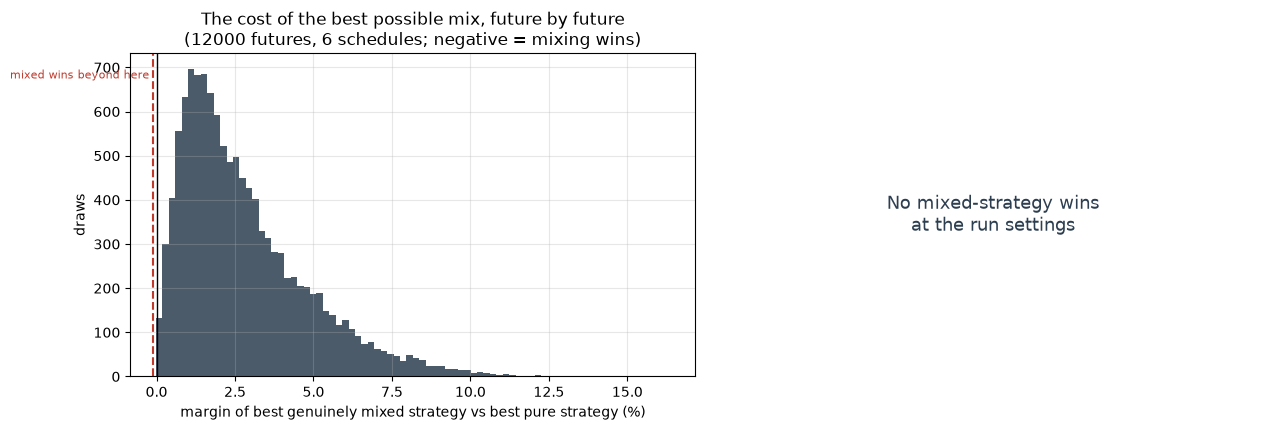

In [17]:
# Figures: the margin distribution (the whole verdict in one panel), and — if any exist —
# the winning share profiles.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
m_all = 100 * _all["margin"].values
ax.hist(m_all, bins=80, color="#2c3e50", alpha=0.85)
ax.axvline(0.0, color="k", lw=1)
ax.axvline(-100 * TOL_WIN, color="#c0392b", ls="--", lw=1.5)
ax.text(-100 * TOL_WIN, ax.get_ylim()[1] * 0.95, f"mixed wins beyond here ",
        color="#c0392b", fontsize=8, va="top", ha="right")
ax.set_xlabel("margin of best genuinely mixed strategy vs best pure strategy (%)")
ax.set_ylabel("draws")
ax.set_title(f"The cost of the best possible mix, future by future\n"
             f"({total_draws} futures, 6 schedules; negative = mixing wins)")
ax.grid(alpha=0.3)

ax = axes[1]
if len(winning):
    order = winning["advantage"].values.argsort()[::-1]
    heat = winning[[f"p_{y}" for y in BUILD_YEARS]].values[order]
    im = ax.imshow(heat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
                   extent=[BUILD_YEARS[0], BUILD_YEARS[-1], len(winning), 0])
    plt.colorbar(im, ax=ax, label="SMR share of the year's builds")
    ax.set_xlabel("build year")
    ax.set_ylabel("winning draws (sorted by advantage)")
    ax.set_title("Optimal share profiles of the winning draws")
else:
    ax.text(0.5, 0.5, "No mixed-strategy wins\nat the run settings",
            ha="center", va="center", fontsize=13, color="#2c3e50",
            transform=ax.transAxes)
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIGURES / "mixed_build_advantage.png", dpi=200, bbox_inches="tight")
plt.show()

## Sensitivity: how strongly do the two relaxed assumptions matter?

Two panels close the loop:

1. **The anchor-cost correlation** `rho_boak`, swept from fully decoupled (0) to the
   companion notebook's comonotone draw (1), on the representative McKinsey schedule with
   common random numbers — so differences between sweep points are pure correlation effects.
2. **Spillover shut off** (`x = 0` forced) on the main draws of every schedule — this should
   drive mixed strategies furthest from winning, reproducing the companion notebook's
   winner-take-all world as a limiting case.

In [18]:
print(f"rho_boak sweep ({SWEEP_SCHED}, {N_SWEEP} draws per point, common random numbers):")
SWEEP_WORLDS, SWEEP_FUNNEL = {}, {}
for rb in RHO_BOAK_SWEEP:
    w = draw_world_4(N_SWEEP, COPULA_SET, rb, rng_stream("mixopt/sweep"))  # same stream => CRN
    SWEEP_WORLDS[rb] = w
    SWEEP_FUNNEL[rb] = run_funnel(w, SWEEP_SCHED, S_KV=intl_stock(w),
                                  label=f"rho_boak={rb}")

sweep_tab = pd.DataFrame({rb: {"P(SMR starts cheaper)": float((SWEEP_WORLDS[rb]["boak_smr"]
                                                               < SWEEP_WORLDS[rb]["boak_large"]).mean()),
                               "P(mixed wins > 0.1%)": float(SWEEP_FUNNEL[rb]["mixed_wins"].mean()),
                               "closest margin": float(SWEEP_FUNNEL[rb]["margin"].min()),
                               "median margin": float(np.median(SWEEP_FUNNEL[rb]["margin"]))}
                          for rb in RHO_BOAK_SWEEP}).T
sweep_tab.index.name = "rho_boak"
sweep_tab.to_csv(EXPORTS / "rho_boak_sweep.csv")
print()
print(sweep_tab.round(4).to_string())

rho_boak sweep (McKinsey GEP 2025, 1000 draws per point, common random numbers):


  rho_boak=0.0                 flagged   20/1000 (near-corner 0, audit-only 20), mixed wins    0 (0.0%), closest margin +0.50%, 4s


  rho_boak=0.5                 flagged   31/1000 (near-corner 1, audit-only 30), mixed wins    0 (0.0%), closest margin +0.47%, 7s


  rho_boak=0.9                 flagged   28/1000 (near-corner 1, audit-only 27), mixed wins    0 (0.0%), closest margin +0.45%, 10s


  rho_boak=1.0                 flagged   30/1000 (near-corner 3, audit-only 27), mixed wins    0 (0.0%), closest margin +0.36%, 12s

          P(SMR starts cheaper)  P(mixed wins > 0.1%)  closest margin  median margin
rho_boak                                                                            
0.0                       0.228                   0.0          0.0050         0.0280
0.5                       0.133                   0.0          0.0047         0.0266
0.9                       0.018                   0.0          0.0045         0.0265
1.0                       0.000                   0.0          0.0036         0.0259


In [19]:
print("cross-tech spillover forced to zero (main draws, all schedules):")
XZERO_FUNNEL = {}
for sched in SCHED_ORDER:
    XZERO_FUNNEL[sched] = run_funnel(WORLDS[sched], sched, S_KV=SKV[sched], x_zero=True,
                                     label=f"xzero/{SCEN_TOKEN[sched]}")
xzero_tab = pd.DataFrame({s: {"P(mixed wins > 0.1%)": float(XZERO_FUNNEL[s]["mixed_wins"].mean()),
                              "closest margin": float(XZERO_FUNNEL[s]["margin"].min())}
                          for s in SCHED_ORDER}).T
xzero_tab.to_csv(EXPORTS / "xzero_verdict.csv")
print()
print(xzero_tab.round(4).to_string())
print("\nComparing 'closest margin' here vs the main run isolates how much the drawn "
      "cross-tech\nspillover moves mixing toward viability.")

cross-tech spillover forced to zero (main draws, all schedules):


  xzero/eia_aeo_high           flagged   57/2000 (near-corner 3, audit-only 54), mixed wins    0 (0.0%), closest margin +0.38%, 11s


  xzero/abou_jaoude            flagged  654/2000 (near-corner 612, audit-only 42), mixed wins    0 (0.0%), closest margin -0.02%, 103s


  xzero/iaea_high              flagged   70/2000 (near-corner 2, audit-only 68), mixed wins    0 (0.0%), closest margin +0.40%, 2s


  xzero/mckinsey               flagged   70/2000 (near-corner 0, audit-only 70), mixed wins    0 (0.0%), closest margin +0.55%, 3s


  xzero/cop28                  flagged   63/2000 (near-corner 0, audit-only 63), mixed wins    0 (0.0%), closest margin +0.61%, 3s


  xzero/eo2025                 flagged   55/2000 (near-corner 0, audit-only 55), mixed wins    0 (0.0%), closest margin +0.63%, 4s

                       P(mixed wins > 0.1%)  closest margin
EIA 2026 AEO high                       0.0          0.0038
Abou-Jaoude mod                         0.0         -0.0002
IAEA high                               0.0          0.0040
McKinsey GEP 2025                       0.0          0.0055
COP28 tripling pledge                   0.0          0.0061
2025 EO                                 0.0          0.0063

Comparing 'closest margin' here vs the main run isolates how much the drawn cross-tech
spillover moves mixing toward viability.


## QA suite

One check per cell, each announcing PASS or FAIL. QA-A/B/C/D pin this notebook to the
companion notebook's engine at the "off" settings; QA-E re-pins the financing port to the
ReEDS engine's regression value; QA-F checks the optimizer's internal consistency; QA-G ties
the zero-spillover limit back to the companion's fragmentation result.

In [20]:
# QA-A — engine parity: with the cross-tech arguments off, the extended experience_channels
# must reproduce the companion notebook's function BIT-FOR-BIT. The companion's exact
# function body is pasted here as the reference implementation.
def _experience_channels_companion(world, tech, n_us):
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_KV = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_KV += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    N_us = np.broadcast_to(np.asarray(n_us, float), (n, T))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + world["s"].values[:, None]*(conv*H_ALL_W + S_KV)
    return own, oth

_w = WORLDS[SWEEP_SCHED]
for tech in TECH:
    n_us = np.cumsum(GW_ADD[SWEEP_SCHED]) / TECH[tech]["unit_gw"]   # tech takes the whole program
    own_a, oth_a = experience_channels(_w, tech, n_us)                       # extension off
    own_b, oth_b = experience_channels(_w, tech, n_us, n_oth=np.zeros(T),
                                       x_in=_w["x_ls"].values)               # extension on, x*0
    own_c, oth_c = _experience_channels_companion(_w, tech, n_us)            # companion verbatim
    assert np.array_equal(own_a, own_c) and np.array_equal(oth_a, oth_c), tech
    assert np.array_equal(own_b, own_c) and np.array_equal(oth_b, oth_c), tech
print("QA-A PASSED: extended experience_channels reproduces the companion engine bit-for-bit "
      "with the cross-tech term off (both by omission and by zero stock)")

QA-A PASSED: extended experience_channels reproduces the companion engine bit-for-bit with the cross-tech term off (both by omission and by zero stock)


In [21]:
# QA-B — anchor identity: OCC(2030) equals the drawn anchor cost for EVERY draw, technology,
# and share profile, even with drawn cross-tech spillover active (the cross-tech stock is
# zero at the anchor by construction, so the anchor can never move).
_rng = rng_stream("mixopt/qa_b")
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    p_full = embed_shares(_rng.random(N_P))
    n_large, n_smr = split_units(sched, p_full)
    for tech, n_own, n_oth, xcol in (("smr", n_smr, n_large, "x_ls"),
                                     ("large", n_large, n_smr, "x_sl")):
        occ = occ_paths_ces(w, tech, n_own, n_oth=n_oth, x_in=w[xcol].values, S_KV=SKV[sched])
        assert np.allclose(occ[:, yi(ANCHOR)], w[f"boak_{tech}"].values), (sched, tech)
print("QA-B PASSED: every draw hits its anchor cost exactly at 2030, "
      "all schedules, both technologies, random share profile, drawn spillover")

QA-B PASSED: every draw hits its anchor cost exactly at 2030, all schedules, both technologies, random share profile, drawn spillover


In [22]:
# QA-C — the split anchor-cost draw: at rho_boak = 1 the comonotone path must place both
# technologies at IDENTICAL percentiles of their ranges (the companion draw); at every
# swept rho_boak the marginals must remain uniform on the published ranges.
_wc = draw_world_4(20000, COPULA_SET, 1.0, rng_stream("mixopt/qa_c"))
_pct_l = (_wc["boak_large"] - TECH["large"]["boak_lo"]) / (TECH["large"]["boak_hi"] - TECH["large"]["boak_lo"])
_pct_s = (_wc["boak_smr"] - TECH["smr"]["boak_lo"]) / (TECH["smr"]["boak_hi"] - TECH["smr"]["boak_lo"])
assert np.allclose(_pct_l, _pct_s), "comonotone path failed to link the percentiles"
for rb in RHO_BOAK_SWEEP:
    wq = draw_world_4(20000, COPULA_SET, rb, rng_stream(f"mixopt/qa_c/{rb}"))
    for tech in TECH:
        lo, hi = TECH[tech]["boak_lo"], TECH[tech]["boak_hi"]
        pv = stats.kstest((wq[f"boak_{tech}"] - lo) / (hi - lo), "uniform").pvalue
        assert pv > 1e-3, (rb, tech, pv)
print("QA-C PASSED: rho_boak=1 reproduces the companion's comonotone draw exactly; "
      "marginals stay uniform on the published ranges at every swept rho_boak")

QA-C PASSED: rho_boak=1 reproduces the companion's comonotone draw exactly; marginals stay uniform on the published ranges at every swept rho_boak


In [23]:
# QA-D — objective consistency: (i) at the corners, the blended program cost equals the
# independently computed pure-technology program score; (ii) the fast single-draw path
# (WorldRow) reproduces the vectorized batch exactly.
for sched in SCHED_ORDER:
    w, skv = WORLDS[sched], SKV[sched]
    w_t = GW_ADD[sched] / DISC
    for tech, p_corner in (("large", np.zeros(N_P)), ("smr", np.ones(N_P))):
        n_us = np.cumsum(GW_ADD[sched]) / TECH[tech]["unit_gw"]
        fc = (occ_paths_ces(w, tech, n_us, S_KV=skv)
              * ccmult_grid(duration_paths(w, tech, n_us), tech) * FIN_REST[tech][None, :])
        direct = fc @ w_t
        blended = program_cost_batch(w, sched, p_corner, S_KV=skv)
        assert np.allclose(direct, blended, rtol=1e-12), (sched, tech)
_rng = rng_stream("mixopt/qa_d")
_w, _skv = WORLDS[SWEEP_SCHED], SKV[SWEEP_SCHED]
for _ in range(20):
    i = int(_rng.integers(len(_w)))
    p = _rng.random(N_P)
    fast = make_draw_objective(_w, i, SWEEP_SCHED, _skv)(p)
    batch = program_cost_batch(_w, SWEEP_SCHED, p, S_KV=_skv)[i]
    assert np.isclose(fast, batch, rtol=1e-12), i
print("QA-D PASSED: corner costs equal the independent pure-technology scores (all schedules), "
      "and the optimizer's fast single-draw path matches the vectorized batch exactly")

QA-D PASSED: corner costs equal the independent pure-technology scores (all schedules), and the optimizer's fast single-draw path matches the vectorized batch exactly


In [24]:
# QA-E — financing regression: the ported IDC multiplier still reproduces the ReEDS learning
# engine's pinned value (nuclear_learning.py self-test: 72 months, 8% nominal, schedule '6').
_ccm = ccmult_from_duration(72.0, 1.08, FIN["sched"]["large"])
assert abs(_ccm - 1.268124) < 1e-5, _ccm
print(f"QA-E PASSED: ccmult(72 mo, 8%, sched '6') = {_ccm:.6f} (ReEDS engine pin: 1.268124)")

QA-E PASSED: ccmult(72 mo, 8%, sched '6') = 1.268124 (ReEDS engine pin: 1.268124)


In [25]:
# QA-F — optimizer internal consistency: polishing can only improve on the screen; every
# winning profile is genuinely mixed; and the random audit sample checks that the free
# optimizer is not finding wins in regions the screen failed to flag.
_missed = 0
for name, fr in list(FUNNEL.items()) + [(f"rho={rb}", SWEEP_FUNNEL[rb]) for rb in RHO_BOAK_SWEEP] \
        + [(f"xzero {s}", XZERO_FUNNEL[s]) for s in SCHED_ORDER]:
    assert (fr["best_mixed"] <= fr["screen"]["best_mixed"] * (1 + 1e-12)).all(), name
    assert np.isfinite(fr["margin"]).all(), name
    if fr["mixed_wins"].any():
        min_share = np.minimum(fr["smr_gw_share"], 1.0 - fr["smr_gw_share"])
        assert (min_share[fr["mixed_wins"]] > 0.01).all(), name
    audit_only = fr["audit"] & ~fr["near"]
    _missed += int((fr["mixed_wins"] & audit_only).sum())
if _missed:
    print(f"QA-F WARNING: {_missed} mixed wins came from audit-only draws the screen did not "
          f"flag — the screening library is too coarse; raise EPS_FLAG or AUDIT_FRAC and rerun.")
else:
    print("QA-F PASSED: polish never worsens the screen, every recorded win is genuinely "
          "mixed, and no mixed win was found on an audit-only draw (the screen flags every "
          "region the optimizer exploits)")

QA-F PASSED: polish never worsens the screen, every recorded win is genuinely mixed, and no mixed win was found on an audit-only draw (the screen flags every region the optimizer exploits)


In [26]:
# QA-G — continuity with the companion notebook: in the limit this notebook shares with it
# (comonotone anchors, zero cross-tech spillover), the 50/50 constant mix should be penalized
# like the companion's fragmentation figure (McKinsey schedule: median ~20%, P90 ~42%).
# Reported, not asserted: different draws and draw counts.
_wg = SWEEP_WORLDS[1.0]
_skvg = intl_stock(_wg)
_c_half = program_cost_batch(_wg, SWEEP_SCHED, np.full(N_P, 0.5), S_KV=_skvg, x_zero=True)
_c_corners = np.stack([program_cost_batch(_wg, SWEEP_SCHED, CANDS[nm], S_KV=_skvg, x_zero=True)
                       for nm in ("pure_large", "pure_smr")])
_pen = 100 * (_c_half / _c_corners.min(axis=0) - 1.0)
print("QA-G (report): 50/50-mix penalty at comonotone anchors + zero cross-tech spillover, "
      f"{SWEEP_SCHED}:")
print(f"  this notebook : median {np.percentile(_pen, 50):.1f}%, P90 {np.percentile(_pen, 90):.1f}%, "
      f"negative in {(_pen < 0).mean():.1%} of draws")
print("  companion S13 : median ~20.2%, P90 ~42% (10,000 draws, its own stream) — "
      "same ballpark expected, not asserted")

QA-G (report): 50/50-mix penalty at comonotone anchors + zero cross-tech spillover, McKinsey GEP 2025:
  this notebook : median 20.2%, P90 42.0%, negative in 0.0% of draws
  companion S13 : median ~20.2%, P90 ~42% (10,000 draws, its own stream) — same ballpark expected, not asserted


## Run metadata

In [27]:
import hashlib
import subprocess
from datetime import datetime, timezone

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    _git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT,
                          capture_output=True, text=True).stdout.strip()
except Exception:
    _git = "unavailable"

meta = {
    "notebook": "mixed_build_optimizer.ipynb",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "fork_git_head": _git,
    "master_seed": MASTER_SEED,
    "stream_prefix": "mixopt/",
    "switches": {"RHO_BOAK": RHO_BOAK, "RHO_BOAK_SWEEP": RHO_BOAK_SWEEP,
                 "X_SPILL_MAX": X_SPILL_MAX, "HIST_CROSS_TECH": HIST_CROSS_TECH,
                 "COPULA_SET": COPULA_SET, "N_DRAWS_OPT": N_DRAWS_OPT, "N_SWEEP": N_SWEEP,
                 "EPS_FLAG": EPS_FLAG, "AUDIT_FRAC": AUDIT_FRAC, "TOL_WIN": TOL_WIN,
                 "SWEEP_SCHED": SWEEP_SCHED},
    "headline": {"total_draws": int(total_draws), "total_mixed_wins": int(total_wins),
                 "win_fraction": float(total_wins / total_draws),
                 "closest_margin": float(min(FUNNEL[s]["margin"].min() for s in SCHED_ORDER))},
    "exports": {p.name: _sha256(p) for p in sorted(EXPORTS.glob("*.csv"))},
}
with open(EXPORTS / "mixed_build_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "notebook": "mixed_build_optimizer.ipynb",
  "generated_utc": "2026-07-31T22:54:59+00:00",
  "fork_git_head": "518e3237e7b3eb361965a86461fa81f28f3eaae1",
  "master_seed": 20260715,
  "stream_prefix": "mixopt/",
  "switches": {
    "RHO_BOAK": 0.5,
    "RHO_BOAK_SWEEP": [
      0.0,
      0.5,
      0.9,
      1.0
    ],
    "X_SPILL_MAX": 0.3,
    "HIST_CROSS_TECH": false,
    "COPULA_SET": "moderate",
    "N_DRAWS_OPT": 2000,
    "N_SWEEP": 1000,
    "EPS_FLAG": 0.005,
    "AUDIT_FRAC": 0.03,
    "TOL_WIN": 0.001,
    "SWEEP_SCHED": "McKinsey GEP 2025"
  },
  "headline": {
    "total_draws": 12000,
    "total_mixed_wins": 0,
    "win_fraction": 0.0,
    "closest_margin": -0.00021887413734533734
  },
  "exports": {
    "rho_boak_sweep.csv": "408676c60c568f18",
    "verdict_by_schedule.csv": "67a32129c3505037",
    "winning_draws.csv": "59bfb7566521a44f",
    "xzero_verdict.csv": "a2a4d75065525d4d"
  }
}


## Closing note

The verdict table in S7 is this notebook's deliverable. Read it as the answer to one question:
*granting mixing every advantage we could defend — up to 30% cross-technology spillover in each
direction, decoupled starting costs, and a per-future optimizer free to choose any year-by-year
technology split — how often, and by how much, does any mixed build program beat simply
committing to the better technology?*

Alongside the companion notebook's fragmentation figure (which prices the 50/50 split under the
paper's baseline conventions), this is the evidence base for the paper's winner-take-all
treatment of the deployment mandate — or, if wins appear above, the precise characterization of
the futures where that treatment would be wrong.